# Distribution

Generate files of multiple decoders of the same code and noise.

In [1]:
unit_shots: int = 100_000
shots: int = 300_000

code: str = "css_rsc(d=7)"
noise: str = "depolarize(p=0.01)"
decoders: list[str] = [
    "mwpf(c=0)",
    "mwpf(c=50)",
    "mwpf(c=200)",
    # "fb",
    # "fb(max_tree_size=0)",
]

slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)

local_maximum_jobs: int = None

gen_json_filename: str = None
trace_json_filename: str = None

samples_dir: str = "./tmp_samples"
trace_dir: str = "./tmp_trace"

In [2]:
# Parameters
code = "css_rsc(d@7)"
noise = "depolarize(p@0.01)"
decoders = ["mwpf(c@0)", "mwpf(c@15)", "mwpf(c@200)"]
gen_json_filename = "capacity-rsc-d7.gen.css-rsc-d-7.depolarize-p-0-01.json"
trace_json_filename = "capacity-rsc-d7.trace.css-rsc-d-7.depolarize-p-0-01.json"
samples_dir = "/Users/wuyue/Documents/GitHub/PaperMWPFEvaluation/distribution/tmp_samples"
trace_dir = "/Users/wuyue/Documents/GitHub/PaperMWPFEvaluation/distribution/tmp_trace"
local_maximum_jobs = 1
unit_shots = 10000000
shots = 1000000000


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
code = code.replace("@", "=")
noise = noise.replace("@", "=")
decoders = [decoder.replace("@", "=").replace(";", ",") for decoder in decoders]

from qec_lego_bench.notebooks.trace_distribution import *

if gen_json_filename is None:
    gen_json_filename = default_gen_json_filename(code=code, noise=noise)
print("saving gen samples results to:", gen_json_filename)
if trace_json_filename is None:
    trace_json_filename = default_trace_json_filename(code=code, noise=noise)
print("saving trace results to:", trace_json_filename)


saving gen samples results to: capacity-rsc-d7.gen.css-rsc-d-7.depolarize-p-0-01.json
saving trace results to: capacity-rsc-d7.trace.css-rsc-d-7.depolarize-p-0-01.json


In [5]:

from qec_lego_bench.notebooks.trace_distribution import *

# check if any decoder requires decomposing errors, if so, use that decoder
representative_decoder: str = "none"
for decoder in decoders:
    if DecoderCli(decoder).decompose_errors:
        representative_decoder = decoder
        break

generate_sample_function = TraceDistributionSampleGenerationMonteCarloFunction(
    unit_shots=unit_shots,
    samples_dir=samples_dir,
)
# generate_sample_function(1, code=code, noise=noise, decoder=representative_decoder, idx=0)

repeats = math.ceil(shots / unit_shots)
jobs = [
    MonteCarloJob(
        code=code,
        noise=noise,
        decoder=representative_decoder,
        idx=i,
    )
    for i in range(repeats)
]

In [6]:
min_shots_submitter = MinShotsSubmitter(shots=1)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    return min_shots_submitter(executor)

In [7]:
# remove json file to force restart since each function job has the result detection logic
if not os.path.exists(samples_dir):
    if os.path.exists(gen_json_filename):
        os.remove(gen_json_filename)

    # Also print version data to the json file
    import stim, qec_lego_bench, sinter

    print("stim.__version__:", stim.__version__)
    print("qec_lego_bench.__version__:", qec_lego_bench.__version__)
    print("sinter.__version__:", sinter.__version__)

    with open(gen_json_filename, "w") as f:
        json.dump(
            {
                "_version": {
                    "stim": stim.__version__,
                    "qec_lego_bench": qec_lego_bench.__version__,
                    "sinter": sinter.__version__,
                },
            },
            f,
        )

if not os.path.exists(samples_dir):
    os.makedirs(samples_dir)

In [8]:
config = MonteCarloExecutorConfig()
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    generate_sample_function,
    jobs,
    config=config,
    filename=gen_json_filename,
    result_type=LogicalErrorResult,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
    local_maximum_jobs=local_maximum_jobs,
)

In [9]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()

def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,914e65,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.6s (0.0min),0,0,0,0.0(0)
1,finished,ddc1ea,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=1)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)
2,finished,2d5c93,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=10)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)
3,finished,922976,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=11)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.6s (0.0min),0,0,0,0.0(0)
4,finished,7c669d,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=12)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)
5,finished,eb55d1,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=13)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.6s (0.0min),0,0,0,0.0(0)
6,finished,1d4964,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=14)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)
7,finished,031176,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=15)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.6s (0.0min),0,0,0,0.0(0)
8,finished,8e243e,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=16)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)
9,finished,fcd6ab,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=17)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,1.5s (0.0min),0,0,0,0.0(0)


''

# We then evaluate individual decoders

In [10]:
# Also print version data to the json file
import stim, qec_lego_bench, sinter

print("stim.__version__:", stim.__version__)
print("qec_lego_bench.__version__:", qec_lego_bench.__version__)
print("sinter.__version__:", sinter.__version__)

# remove json file to force restart since each function job has the result detection logic
brand_new_run = False
if not os.path.exists(trace_dir):
    brand_new_run = True
    if os.path.exists(trace_json_filename):
        os.remove(trace_json_filename)

    with open(trace_json_filename, "w") as f:
        json.dump(
            {
                "_version": {
                    "stim": stim.__version__,
                    "qec_lego_bench": qec_lego_bench.__version__,
                    "sinter": sinter.__version__,
                },
            },
            f,
        )

if not os.path.exists(trace_dir):
    os.makedirs(trace_dir)

stim.__version__: 1.14.0
qec_lego_bench.__version__: 0.0.post1.dev101+gd11eccf
sinter.__version__: 1.14.0


In [11]:

trace_function = TraceDistributionMonteCarloFunction(
    unit_shots=unit_shots,
    samples_dir=samples_dir,
    trace_dir=trace_dir,
)
# trace_function(1, code=code, noise=noise, decoder=decoders[0], idx=0)

trace_jobs = [
    MonteCarloJob(
        code=code,
        noise=noise,
        decoder=decoder,
        idx=i,
    )
    for i in range(repeats)
    for decoder in decoders
]

In [12]:
trace_executor = MonteCarloJobExecutor(
    trace_function,
    trace_jobs,
    config=config,
    filename=trace_json_filename,
    result_type=LogicalErrorResult,
)

In [13]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()

def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


trace_executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,a73fa0,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,124.2s (2.1min),0,0,0,0.0(0)
1,finished,b82e3a,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=1)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,123.1s (2.1min),0,0,0,0.0(0)
2,finished,cc10ee,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=10)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,133.0s (2.2min),0,0,0,0.0(0)
3,finished,bc1606,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=11)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,134.1s (2.2min),0,0,0,0.0(0)
4,finished,f5d310,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=12)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,131.3s (2.2min),0,0,0,0.0(0)
5,finished,3a0833,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=13)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,133.7s (2.2min),0,0,0,0.0(0)
6,finished,6f38b6,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=14)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,131.0s (2.2min),0,0,0,0.0(0)
7,finished,f775f4,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=15)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,132.8s (2.2min),0,0,0,0.0(0)
8,finished,2ce162,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=16)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,131.0s (2.2min),0,0,0,0.0(0)
9,finished,41cca8,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=17)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,131.9s (2.2min),0,0,0,0.0(0)


''

# Plot the time distribution of individual decoders

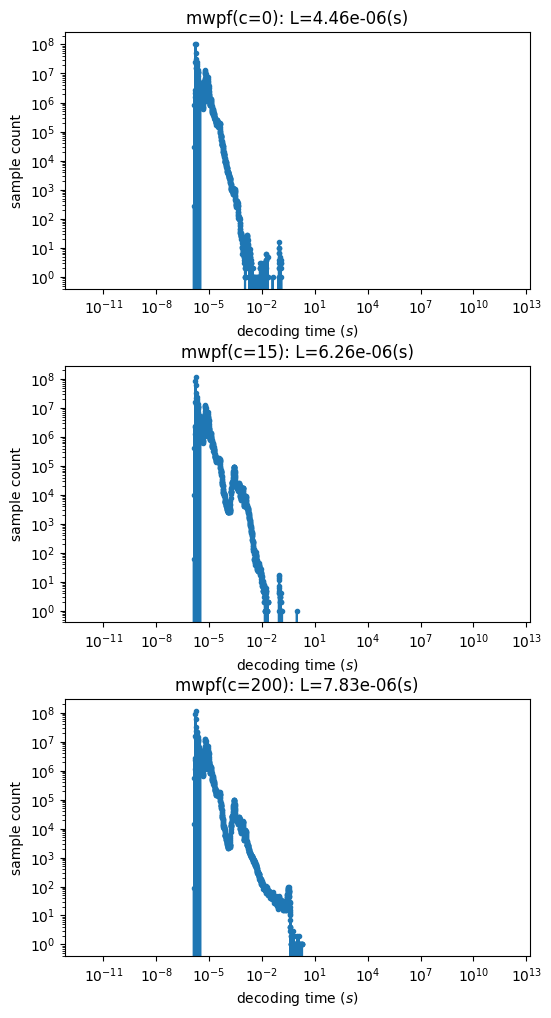


loading mwpf(c=0) time distribution from file:   0%|                                                  | 0/100 [00:00<?, ?it/s]


loading mwpf(c=0) time distribution from file:   1%|▍                                         | 1/100 [00:19<31:22, 19.01s/it]


loading mwpf(c=0) time distribution from file:   2%|▊                                         | 2/100 [00:37<31:01, 19.00s/it]


loading mwpf(c=0) time distribution from file:   3%|█▎                                        | 3/100 [00:56<30:39, 18.97s/it]


loading mwpf(c=0) time distribution from file:   4%|█▋                                        | 4/100 [01:16<30:42, 19.19s/it]

...


loading mwpf(c=200) time distribution from file:  97%|█████████████████████████████████████▊ | 97/100 [42:47<01:25, 28.50s/it]


loading mwpf(c=200) time distribution from file:  98%|██████████████████████████████████████▏| 98/100 [43:07<00:51, 25.86s/it]


loading mwpf(c=200) time distribution from file:  99%|██████████████████████████████████████▌| 99/100 [43:29<00:24, 24.67s/it]


loading mwpf(c=200) time distribution from file: 100%|██████████████████████████████████████| 100/100 [44:01<00:00, 26.93s/it]


loading mwpf(c=200) time distribution from file: 100%|██████████████████████████████████████| 100/100 [44:01<00:00, 26.41s/it]

In [14]:
plotter = TraceTimeDistributionPlotter(
    unit_shots=unit_shots,
    repeats=repeats,
    trace_dir=trace_dir,
    code=code,
    noise=noise,
    basename=gen_json_filename.split(".")[0],
)
if brand_new_run:
    for decoder in decoders:
        if os.path.exists(plotter.result_filename(decoder)):
            os.remove(plotter.result_filename(decoder))
plotter(decoders=decoders)